In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/engine_failure_dataset.csv')

print("Dimenzije skupa podataka (redovi, kolone):")
print(df.shape)

print("\nPrvih 5 redova u tabeli:")
display(df.head())

print("\nBroj nedostajućih vrednosti po kolonama:")
print(df.isnull().sum())

Dimenzije skupa podataka (redovi, kolone):
(1000, 11)

Prvih 5 redova u tabeli:


,Time_Stamp,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,2024-12-24 10:00:00,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,Idle
1,2024-12-24 10:05:00,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,2024-12-24 10:10:00,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,2024-12-24 10:15:00,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,2024-12-24 10:20:00,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising



Broj nedostajućih vrednosti po kolonama:
Time_Stamp           0
Temperature (°C)     0
RPM                  0
Fuel_Efficiency      0
Vibration_X          0
Vibration_Y          0
Vibration_Z          0
Torque               0
Power_Output (kW)    0
Fault_Condition      0
Operational_Mode     0
dtype: int64


In [16]:
if 'Time_Stamp' in df.columns:
    df = df.drop(columns=['Time_Stamp'])
    print("Kolona 'Time_Stamp' je uspešno uklonjena!")
else:
    print("Kolona 'Time_Stamp' ne postoji ili je već uklonjena.")

# Enkodiranje za tekstualnu kolonu 'Operational_Mode'
# get_dummies stvara zasebne kolone za Idle, Cruising i Heavy Load sa vrednostima 0 i 1
df_encoded = pd.get_dummies(df, columns=['Operational_Mode'], dtype=int)

print("\n--- Izgled podataka nakon enkodiranja (Prvih 5 redova) ---")
display(df_encoded.head())

print("\nNove dimenzije tabele (redovi, kolone):")
print(df_encoded.shape)

Kolona 'Time_Stamp' ne postoji ili je već uklonjena.

--- Izgled podataka nakon enkodiranja (Prvih 5 redova) ---


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode_Cruising,Operational_Mode_Heavy Load,Operational_Mode_Idle
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,0,0,1
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,1,0,0
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,1,0,0
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,1,0,0
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,1,0,0



Nove dimenzije tabele (redovi, kolone):
(1000, 12)


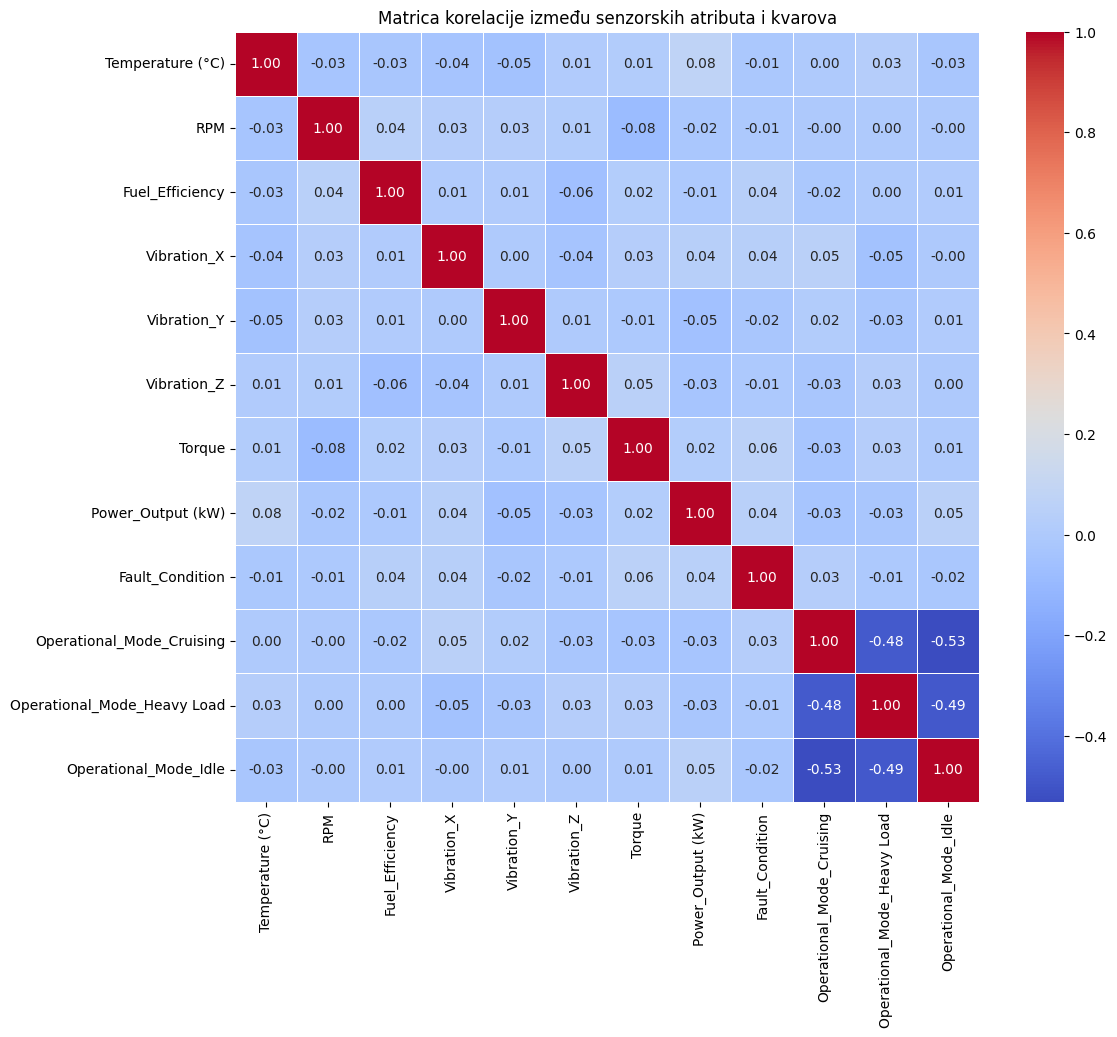

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Računanje matrice korelacije
corr_matrix = df_encoded.corr()

# Podešavanje veličine grafikona
plt.figure(figsize=(12, 10))

# Crtanje toplotne mape 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matrica korelacije između senzorskih atributa i kvarova')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Fault_Condition'])
y = df_encoded['Fault_Condition']

# Prva podela: TEST SKUP (20%) 
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Druga podela: Od preostalih 80% privremeni trening i validacioni skup 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

print("--- BEZBEDNA PODELA PODATAKA IZVRŠENA ---")
print(f"Broj uzoraka za treniranje (64%): {X_train.shape[0]}")
print(f"Broj uzoraka za validaciju (16%): {X_val.shape[0]}")
print(f"Broj uzoraka za KONAČNI TEST (20%): {X_test.shape[0]} ")

--- BEZBEDNA PODELA PODATAKA IZVRŠENA ---
Broj uzoraka za treniranje (64%): 640
Broj uzoraka za validaciju (16%): 160
Broj uzoraka za KONAČNI TEST (20%): 200 


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_tree = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Treniranje modela na trening skupu
model_tree.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Provera modela na validacionom skupu 
y_pred_val_tree = model_tree.predict(X_val)
y_pred_val_rf = model_rf.predict(X_val)

acc_val_tree = accuracy_score(y_val, y_pred_val_tree)
acc_val_rf = accuracy_score(y_val, y_pred_val_rf)

print("=============================================")
print(f"Validaciona tačnost Stabla odlučivanja: {acc_val_tree * 100:.2f}%")
print(f"Validaciona tačnost Slučajne šume (Random Forest): {acc_val_rf * 100:.2f}%")
print("=============================================\n")

print("--- DETALJAN IZVEŠTAJ ZA VALIDACIONI SKUP (RANDOM FOREST) ---")
print(classification_report(y_val, y_pred_val_rf))

Validaciona tačnost Stabla odlučivanja: 27.50%
Validaciona tačnost Slučajne šume (Random Forest): 20.00%

--- DETALJAN IZVEŠTAJ ZA VALIDACIONI SKUP (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.24      0.22      0.23        41
           1       0.13      0.12      0.13        40
           2       0.23      0.24      0.23        42
           3       0.21      0.22      0.21        37

    accuracy                           0.20       160
   macro avg       0.20      0.20      0.20       160
weighted avg       0.20      0.20      0.20       160



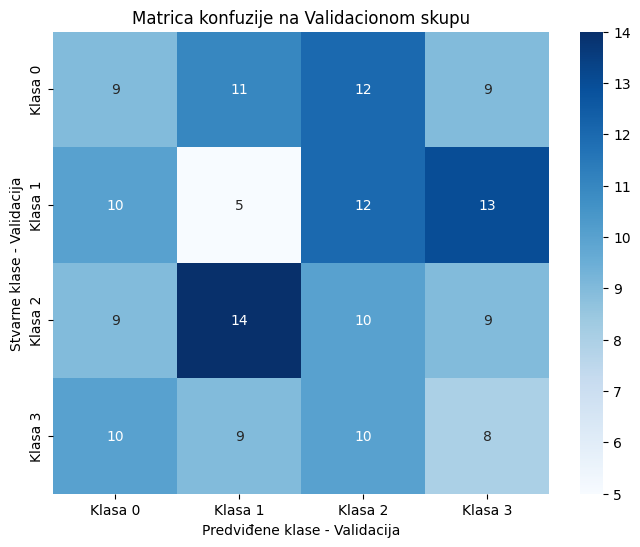

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_val = confusion_matrix(y_val, y_pred_val_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Klasa 0', 'Klasa 1', 'Klasa 2', 'Klasa 3'],
            yticklabels=['Klasa 0', 'Klasa 1', 'Klasa 2', 'Klasa 3'])

plt.ylabel('Stvarne klase - Validacija')
plt.xlabel('Predviđene klase - Validacija')
plt.title('Matrica konfuzije na Validacionom skupu')
plt.show()